# Attack outcome composition

This notebook partitions every requested ranking instance into three mutually exclusive outcomes: **discarded**, **attack success**, and **valid attack failure**. It reads the portable `Results/attack_outcomes.csv`, which is updated on the machine holding new JSONL results, and creates one stacked bar-chart block per available attack type, including Query Injection (QI).

- **Discarded**: requested instances that did not produce a valid attacked ranking, including clean-stage exclusions.
- **Attack success**: valid attacked rankings that meet the paradigm's registered success condition.
- **Valid attack failure**: valid attacked rankings that do not meet that success condition.

All percentages use the original requested-instance count as their denominator, so discarded outputs are never counted as attack successes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd()
if not (ROOT / 'LLM_prompt_attack').exists():
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / 'Results'
OUTCOME_CSV = RESULTS_DIR / 'attack_outcomes.csv'
if not OUTCOME_CSV.exists():
    raise FileNotFoundError(
        f'{OUTCOME_CSV} is missing. Run Results/update_attack_outcomes.py first.'
    )

selected_runs = pd.read_csv(OUTCOME_CSV).sort_values(
    ['Attack', 'Dataset', 'Paradigm', 'Model', 'Prompt']
).reset_index(drop=True)

selected_runs


,Dataset,Model,Paradigm,Attack,Prompt,Requested,Valid attacked,Discarded,Attack success,Valid attack failure,Date,Source,Line,Discarded (%),Attack success (%),Valid attack failure (%)
0,TREC-DL-2019,GPT-OSS-20B,Pairwise,DCH,Default,4096,4056,40,4056,0,2026-09-03 14:18:33,LLM_prompt_attack/outputs/result_GPT-OSS-20B_t...,1,0.976562,99.023438,0.000000
1,TREC-DL-2019,GPT-OSS-20B,Pairwise,DCH,Defense,4096,3393,703,239,3154,2026-09-03 16:55:35,LLM_prompt_attack/outputs/result_GPT-OSS-20B_t...,1,17.163086,5.834961,77.001953
2,TREC-DL-2019,Llama3 70B,Pairwise,DCH,Default,4096,4096,0,4095,1,2026-09-03 19:36:25,LLM_prompt_attack/outputs/result_Llama-3-70B_t...,1,0.000000,99.975586,0.024414
3,TREC-DL-2019,Qwen3-32B,Pairwise,DCH,Default,4096,4096,0,3972,124,2026-08-31 12:56:02,LLM_prompt_attack/outputs/result_Qwen3-32B_pai...,1,0.000000,96.972656,3.027344
4,TREC-DL-2019,Qwen3-32B,Pairwise,DCH,Defense,4096,4096,0,663,3433,2026-08-31 12:30:15,LLM_prompt_attack/outputs/result_Qwen3-32B_pai...,1,0.000000,16.186523,83.813477
5,TREC-DL-2019,Qwen3-4B,Pairwise,DCH,Default,4096,4096,0,3128,968,2026-09-02 12:57:00,LLM_prompt_attack/outputs/result_Qwen3-4B_pair...,1,0.000000,76.367188,23.632812
6,TREC-DL-2019,Qwen3-4B,Pairwise,DCH,Defense,4096,4096,0,446,3650,2026-09-02 17:26:26,LLM_prompt_attack/outputs/result_Qwen3-4B_trec...,1,0.000000,10.888672,89.111328
7,TREC-DL-2019,Qwen3-32B,Setwise,DCH,Default,4096,4065,31,3885,180,2026-09-04 01:58:19,LLM_prompt_attack/outputs/result_GPT-OSS-20B_t...,1,0.756836,94.848633,4.394531
8,TREC-DL-2019,Qwen3-32B,Setwise,DCH,Defense,4096,4096,0,3087,1009,2026-09-04 02:13:17,LLM_prompt_attack/outputs/result_GPT-OSS-20B_t...,1,0.000000,75.366211,24.633789
9,TREC-DL-2019,Qwen3-4B,Setwise,DCH,Defense,4096,4086,10,1233,2853,2026-09-02 19:55:52,LLM_prompt_attack/outputs/result_Qwen3-4B_trec...,1,0.244141,30.102539,69.653320


## Outcome table

Each row sums to 100% of requested instances. The count columns make the denominator explicit.

In [2]:
outcome_columns = [
    'Dataset', 'Model', 'Paradigm', 'Attack', 'Prompt', 'Requested',
    'Discarded', 'Attack success', 'Valid attack failure',
    'Discarded (%)', 'Attack success (%)', 'Valid attack failure (%)',
]
outcome_table = selected_runs[outcome_columns].copy()
outcome_table


,Dataset,Model,Paradigm,Attack,Prompt,Requested,Discarded,Attack success,Valid attack failure,Discarded (%),Attack success (%),Valid attack failure (%)
0,TREC-DL-2019,GPT-OSS-20B,Pairwise,DCH,Default,4096,40,4056,0,0.976562,99.023438,0.000000
1,TREC-DL-2019,GPT-OSS-20B,Pairwise,DCH,Defense,4096,703,239,3154,17.163086,5.834961,77.001953
2,TREC-DL-2019,Llama3 70B,Pairwise,DCH,Default,4096,0,4095,1,0.000000,99.975586,0.024414
3,TREC-DL-2019,Qwen3-32B,Pairwise,DCH,Default,4096,0,3972,124,0.000000,96.972656,3.027344
4,TREC-DL-2019,Qwen3-32B,Pairwise,DCH,Defense,4096,0,663,3433,0.000000,16.186523,83.813477
5,TREC-DL-2019,Qwen3-4B,Pairwise,DCH,Default,4096,0,3128,968,0.000000,76.367188,23.632812
6,TREC-DL-2019,Qwen3-4B,Pairwise,DCH,Defense,4096,0,446,3650,0.000000,10.888672,89.111328
7,TREC-DL-2019,Qwen3-32B,Setwise,DCH,Default,4096,31,3885,180,0.756836,94.848633,4.394531
8,TREC-DL-2019,Qwen3-32B,Setwise,DCH,Defense,4096,0,3087,1009,0.000000,75.366211,24.633789
9,TREC-DL-2019,Qwen3-4B,Setwise,DCH,Defense,4096,10,1233,2853,0.244141,30.102539,69.653320


## Stacked outcome charts

Each model has one Default bar and, where available, one Defense bar. The three stacks always sum to 100% of requested instances.

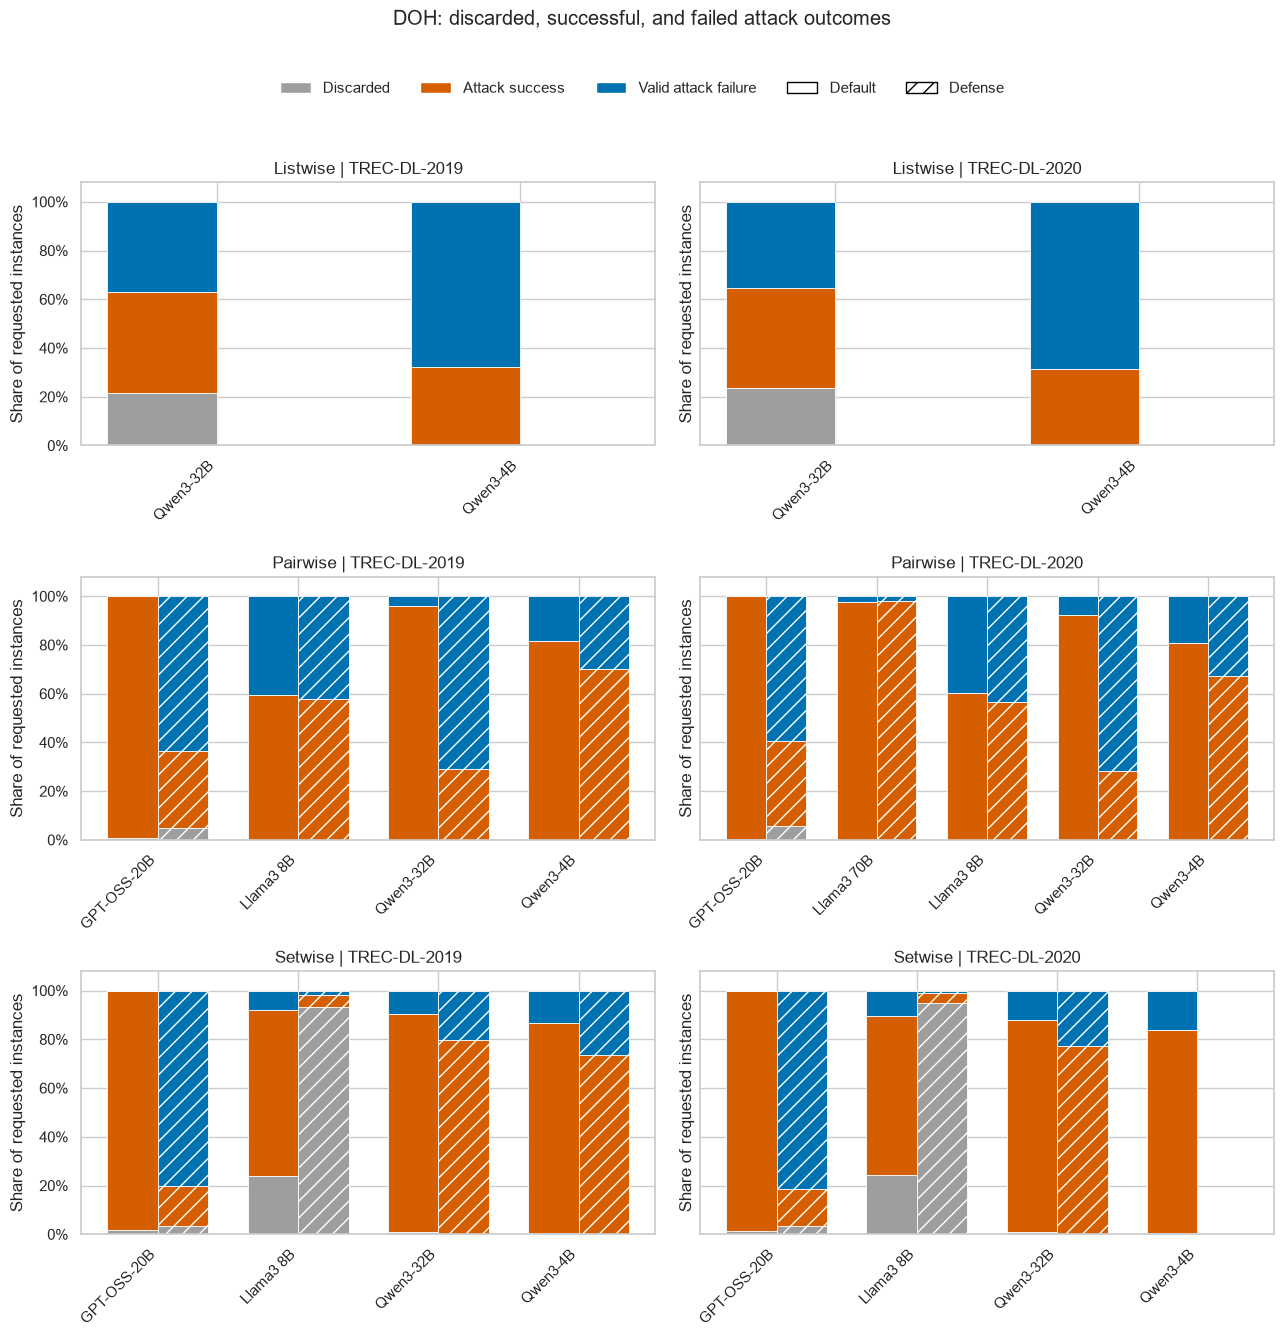

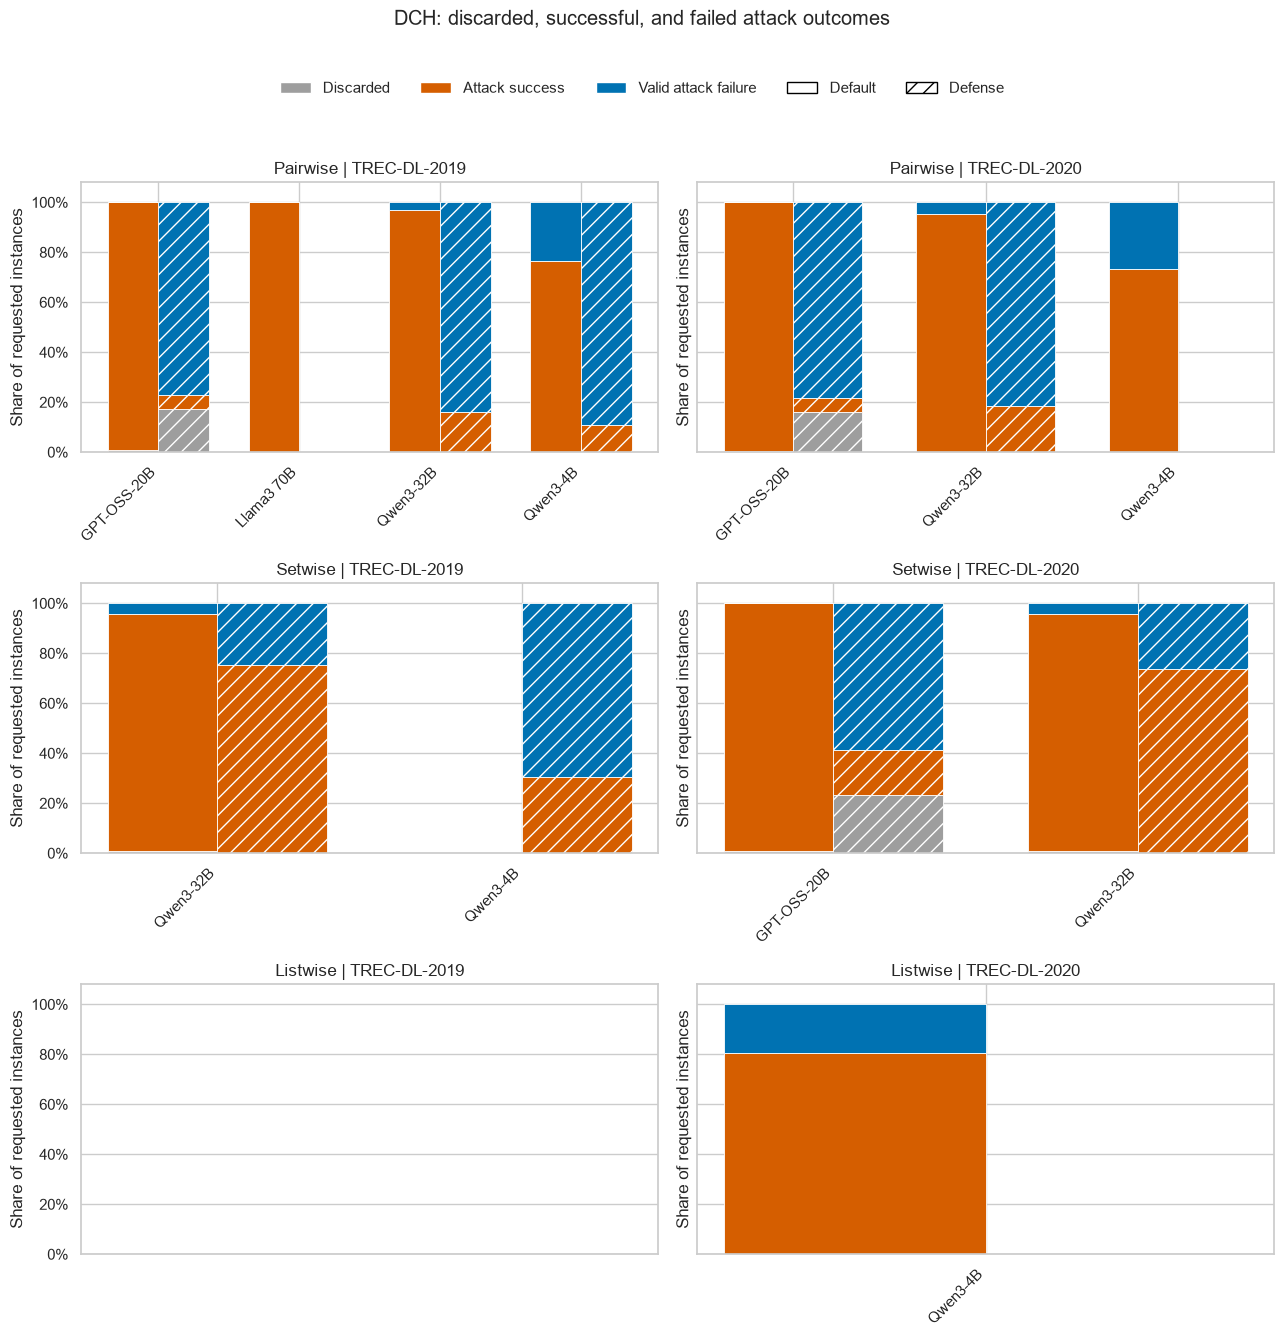

In [3]:
sns.set_theme(style='whitegrid', context='notebook')
outcomes = ['Discarded', 'Attack success', 'Valid attack failure']
colors = {
    'Discarded': '#9E9E9E',
    'Attack success': '#D55E00',
    'Valid attack failure': '#0072B2',
}
prompt_order = ['Default', 'Defense']

for attack in selected_runs['Attack'].drop_duplicates():
    attack_data = selected_runs[selected_runs['Attack'] == attack]
    if attack_data.empty:
        continue

    datasets = list(dict.fromkeys(attack_data['Dataset']))
    paradigms = list(dict.fromkeys(attack_data['Paradigm']))
    figure, axes = plt.subplots(
        len(paradigms), len(datasets),
        figsize=(6.5 * len(datasets), 4.3 * len(paradigms)),
        squeeze=False,
        sharey=True,
    )

    for row_index, paradigm in enumerate(paradigms):
        for column_index, dataset in enumerate(datasets):
            axis = axes[row_index, column_index]
            panel = attack_data[
                (attack_data['Paradigm'] == paradigm)
                & (attack_data['Dataset'] == dataset)
            ]
            models = list(dict.fromkeys(panel['Model']))
            x_positions = range(len(models))
            bar_width = 0.36

            for prompt_index, prompt in enumerate(prompt_order):
                prompt_panel = panel[panel['Prompt'] == prompt].set_index('Model')
                bottom = [0.0] * len(models)
                offset = (prompt_index - 0.5) * bar_width
                for outcome in outcomes:
                    values = [
                        prompt_panel.loc[model, f'{outcome} (%)']
                        if model in prompt_panel.index else 0.0
                        for model in models
                    ]
                    bars = axis.bar(
                        [position + offset for position in x_positions],
                        values,
                        width=bar_width,
                        bottom=bottom,
                        color=colors[outcome],
                        edgecolor='white',
                        linewidth=0.6,
                        hatch='//' if prompt == 'Defense' else None,
                    )
                    bottom = [current + value for current, value in zip(bottom, values)]
            axis.set_title(f'{paradigm} | {dataset}')
            axis.set_xticks(list(x_positions), models, rotation=45, ha='right')
            axis.set_ylim(0, 108)
            axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
            axis.set_ylabel('Share of requested instances')

    outcome_handles = [Patch(facecolor=colors[outcome], label=outcome) for outcome in outcomes]
    prompt_handles = [
        Patch(facecolor='white', edgecolor='black', label='Default'),
        Patch(facecolor='white', edgecolor='black', hatch='//', label='Defense'),
    ]
    figure.legend(
        outcome_handles + prompt_handles,
        outcomes + ['Default', 'Defense'],
        loc='upper center',
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, 0.99),
    )
    figure.suptitle(f'{attack}: discarded, successful, and failed attack outcomes', y=1.035)
    figure.tight_layout(rect=(0, 0, 1, 0.96))
    slug = attack.lower().replace(' ', '_')
    figure.savefig(RESULTS_DIR / f'attack_outcome_composition_{slug}.pdf', bbox_inches='tight')
    figure.savefig(RESULTS_DIR / f'attack_outcome_composition_{slug}.png', dpi=300, bbox_inches='tight')
    plt.show()
